In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_excel("Online_Retail.xlsx")
print("Initial shape:",df.shape)
df.head()

Initial shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
# Missing Value Check
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
a = df['CustomerID'].count()
a

np.int64(406829)

In [7]:
#Removing Missing Customerid
df_clean = df.dropna(subset = ['CustomerID']).copy()
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)
print("After removing missing CustomerID:",df_clean.shape)

After removing missing CustomerID: (406829, 8)


In [8]:
#Remove Cancelled Orders & Invalid Prices
df_clean = df_clean[(df_clean['Quantity']>0) & (df_clean['UnitPrice']>0)]
print("After removing cancelledorders:",df_clean.shape)

After removing cancelledorders: (397884, 8)


In [9]:
#Create TotalPrice Column
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [10]:
#Checking Cleaned Data Summary
print("Total Unique Customers: ",df_clean['CustomerID'].nunique())
print("Total Unique Products:",df_clean['StockCode'].nunique())
print("Total Countries: ",df_clean['Country'].nunique())
print("Date Range:",df_clean['InvoiceDate'].min(),"to",df_clean['InvoiceDate'].max())
print("Total Revenue:",round(df_clean['TotalPrice'].sum(),2))

Total Unique Customers:  4338
Total Unique Products: 3665
Total Countries:  37
Date Range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Total Revenue: 8911407.9


C:\Users\neela\AppData\Local\Temp\ipykernel_24064\4179943213.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_rev.values, y=country_rev.index, palette='viridis')


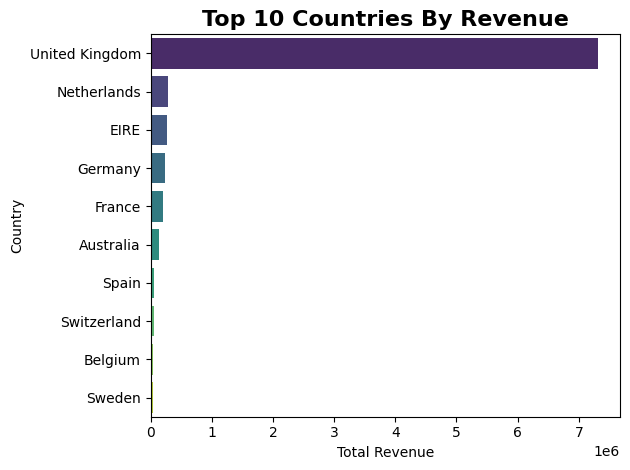

In [11]:
#Top 10 Countries By Revenue
country_rev = df_clean.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=country_rev.values, y=country_rev.index, palette='viridis')
plt.title('Top 10 Countries By Revenue',fontsize=16,fontweight ='bold')
plt.xlabel("Total Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [12]:
#Monthly Revenue Trend
df_clean['InvoiceMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
monthly_rev = df_clean.groupby('InvoiceMonth')['TotalPrice'].sum()


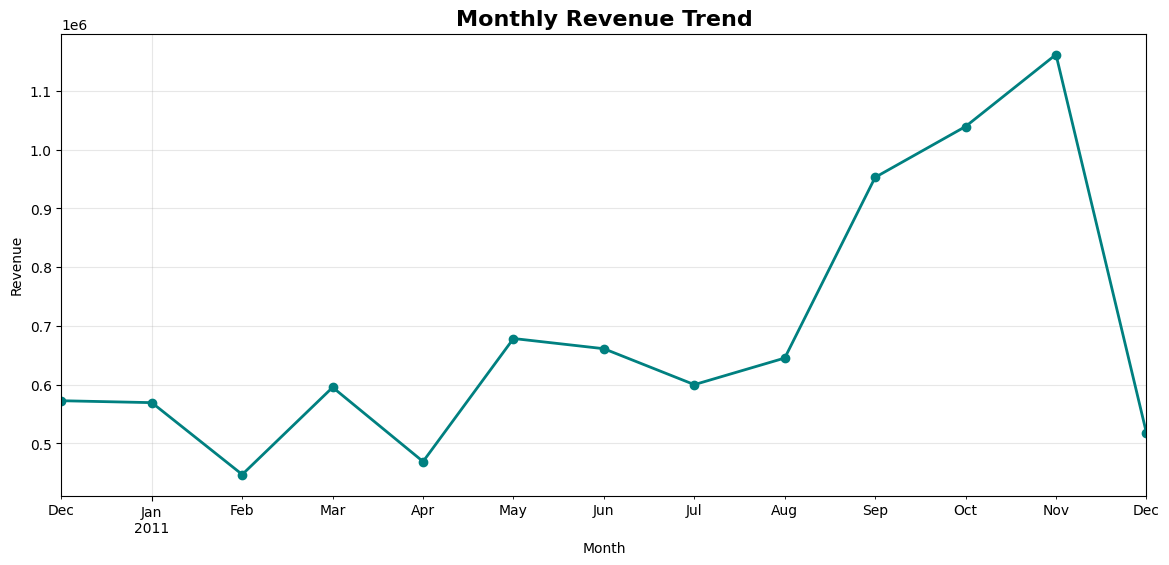

In [13]:
plt.figure(figsize=(14,6))
monthly_rev.plot(kind='line',marker= 'o',color='teal',linewidth=2)
plt.title('Monthly Revenue Trend', fontsize=16,fontweight = 'bold')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True,alpha=0.3)

In [14]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,InvoiceMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12


In [15]:
#Top 10 Best Selling Products
top_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending = False).head(10)
top_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

C:\Users\neela\AppData\Local\Temp\ipykernel_24064\2527852101.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values,y=top_products.index,palette='magma')


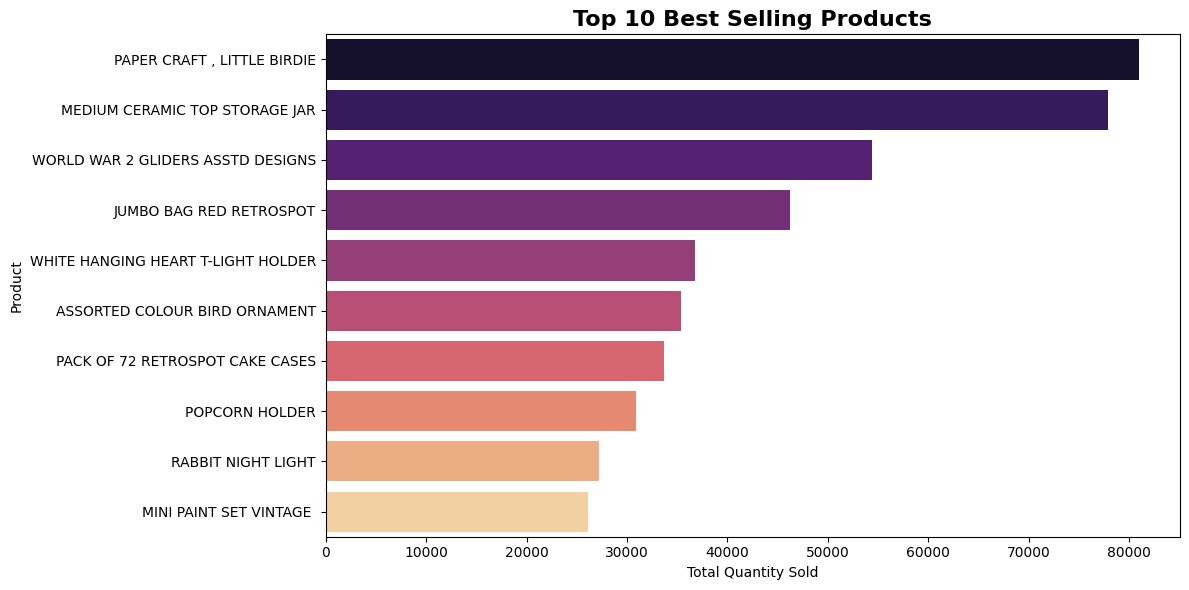

In [16]:
#chart

plt.figure(figsize=(12,6))
sns.barplot(x=top_products.values,y=top_products.index,palette='magma')
plt.title('Top 10 Best Selling Products',fontsize =16,fontweight='bold')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

C:\Users\neela\AppData\Local\Temp\ipykernel_24064\508791191.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = orders_by_day.index ,y = orders_by_day.values,palette='coolwarm')


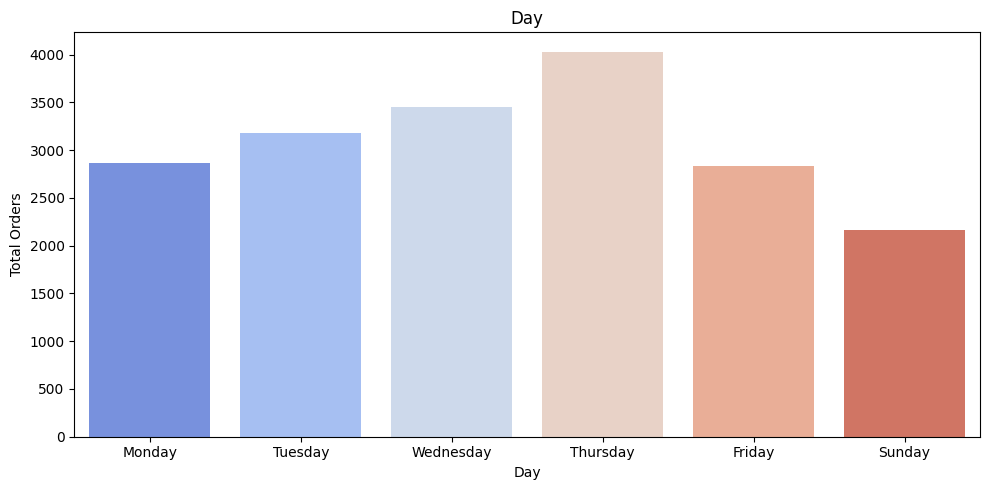

In [17]:
#Order by Day Of week
df_clean['DayofWeek'] = df_clean['InvoiceDate'].dt.day_name()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Sunday']
orders_by_day = df_clean.groupby('DayofWeek')['InvoiceNo'].nunique().reindex(day_order)

plt.figure(figsize=(10,5))
sns.barplot(x = orders_by_day.index ,y = orders_by_day.values,palette='coolwarm')
plt.title('Day')
plt.xlabel('Day')
plt.ylabel('Total Orders')
plt.tight_layout()
plt.show()

In [18]:
#Peak Shopping Hours

df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour
hourly_orders = df_clean.groupby('Hour')['InvoiceNo'].nunique()

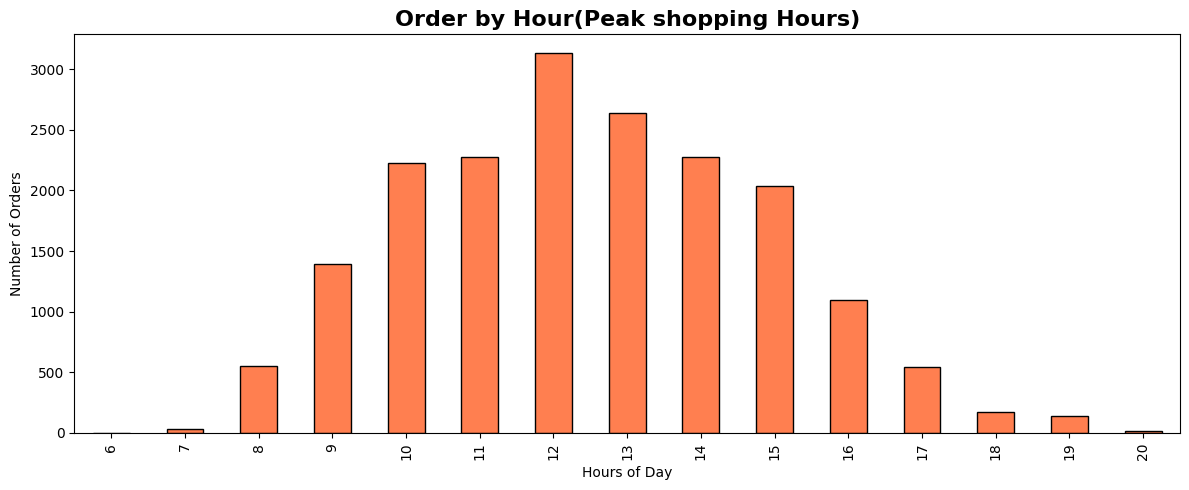

In [19]:
plt.figure(figsize=(12,5))
hourly_orders.plot(kind = 'bar',color='coral',edgecolor='black')
plt.title('Order by Hour(Peak shopping Hours)',fontsize=16,fontweight='bold')
plt.xlabel('Hours of Day')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

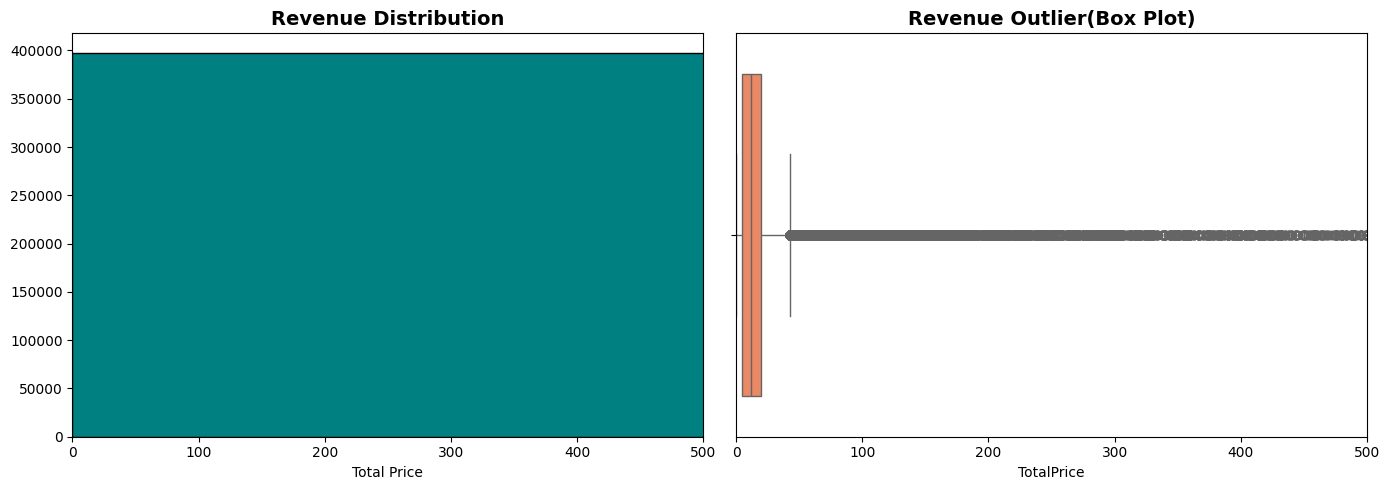

In [20]:
#
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Histogram
axes[0].hist(df_clean['TotalPrice'], bins=50, color='teal', edgecolor='black')
axes[0].set_title('Revenue Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Price')
axes[0].set_xlim(0, 500)

# Box plot
sns.boxplot(x=df_clean['TotalPrice'],ax = axes[1],color ='coral')
axes[1].set_title("Revenue Outlier(Box Plot)",fontsize = 14,fontweight='bold')
axes[1].set_xlim(0,500)

plt.tight_layout()
plt.show()

In [21]:
#Detecting Outlier
df_clean[['Quantity','UnitPrice','TotalPrice']].describe()

,Quantity,UnitPrice,TotalPrice
count,397884.000000,397884.000000,397884.000000
mean,12.988238,3.116488,22.397000
std,179.331775,22.097877,309.071041
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.680000
50%,6.000000,1.950000,11.800000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


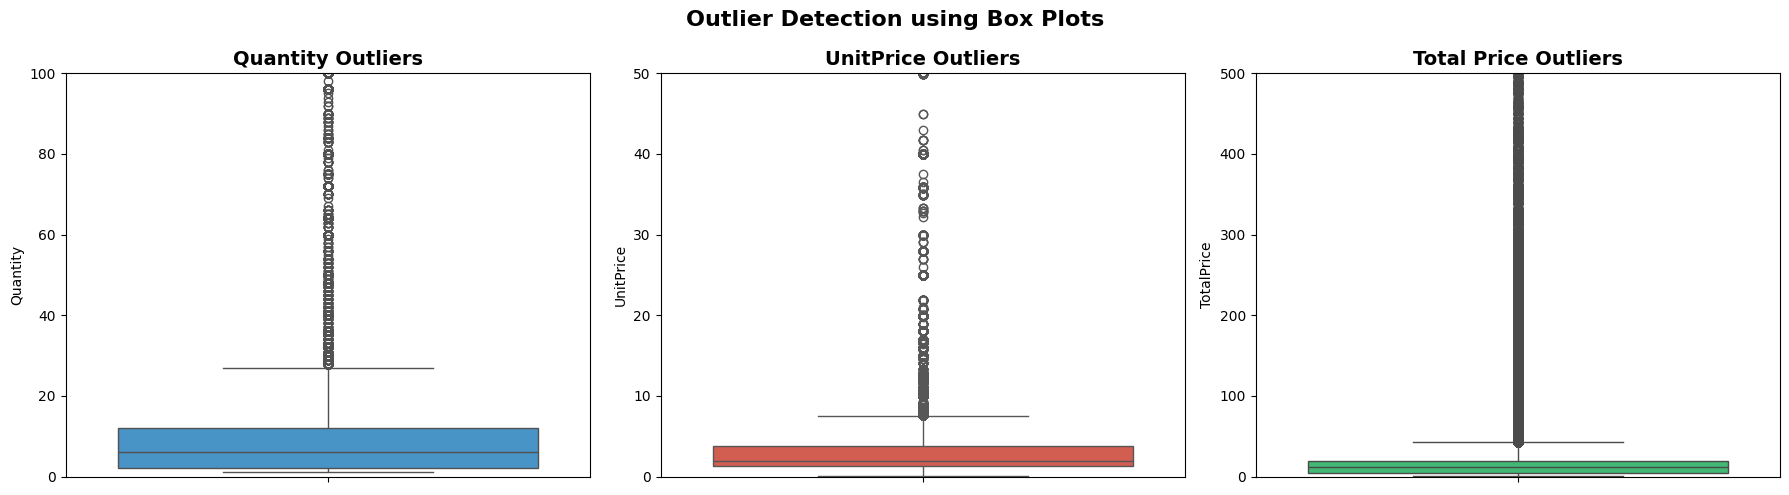

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=df_clean['Quantity'],ax=axes[0],color="#3498db")
axes[0].set_title('Quantity Outliers',fontsize=14,fontweight='bold')
axes[0].set_ylim(0,100)

sns.boxplot(y = df_clean['UnitPrice'],ax=axes[1],color ='#e74c3c')
axes[1].set_title('UnitPrice Outliers',fontsize = 14,fontweight='bold')
axes[1].set_ylim(0,50)

sns.boxplot(y=df_clean['TotalPrice'],ax=axes[2],color='#2ecc71')
axes[2].set_title('Total Price Outliers',fontsize=14,fontweight='bold')
axes[2].set_ylim(0,500)

plt.suptitle('Outlier Detection using Box Plots',fontsize=16,fontweight='bold')
plt.tight_layout()
plt.show()


In [24]:
#Save cleaned CSV
df_clean.to_csv(r"C:\Users\neela\Downloads\Retail-Customer-Analytics-RFM-Cohort\retails.csv", index=False)